# CEJ 定位演算法

## Step1: CEJ locating：test set 載入

此 cell 載入 `data/yolo_tooth/images/test/` 的未增強 test images 與相對應的 YOLO labels。test image 的檔名數字即為 `data/original/` 的影像 index，因此可用 `images[index]`、`dataset_labels[index]` 與 `original_image_paths[index]` 存取同一張影像的資料。

In [2]:
from pathlib import Path

import cv2
import numpy as np


def find_project_root(start: Path) -> Path:
    """Find the repository root whether the notebook is run from root or notebooks/."""
    for directory in (start, *start.parents):
        if (directory / 'data' / 'yolo_tooth').is_dir():
            return directory
    raise FileNotFoundError('Cannot find data/yolo_tooth from the current working directory.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
TEST_IMAGE_DIR = PROJECT_ROOT / 'data' / 'yolo_tooth' / 'images' / 'test'
TEST_LABEL_DIR = PROJECT_ROOT / 'data' / 'yolo_tooth' / 'labels' / 'test'
ORIGINAL_IMAGE_DIR = PROJECT_ROOT / 'data' / 'original'

# The image stem is the corresponding data/original image index (e.g. 2.png -> */2.jpg).
original_indices = sorted(int(path.stem) for path in TEST_IMAGE_DIR.glob('*.png'))
image_paths = {index: TEST_IMAGE_DIR / f'{index}.png' for index in original_indices}
label_paths = {index: TEST_LABEL_DIR / f'{index}.txt' for index in original_indices}
original_image_paths = {
    index: next(ORIGINAL_IMAGE_DIR.rglob(f'{index}.jpg'), None)
    for index in original_indices
}

if missing_labels := [index for index, path in label_paths.items() if not path.is_file()]:
    raise FileNotFoundError(f'Missing YOLO label files for indices: {missing_labels}')
if missing_originals := [index for index, path in original_image_paths.items() if path is None]:
    raise FileNotFoundError(f'Missing data/original images for indices: {missing_originals}')

# YOLO columns: class_id, x_center, y_center, width, height (all coordinates normalized).
dataset_labels = {
    index: np.loadtxt(label_paths[index], dtype=np.float32, ndmin=2)
    for index in original_indices
}
if invalid_labels := [index for index, label in dataset_labels.items() if label.shape[1] != 5]:
    raise ValueError(f'YOLO labels must have 5 columns; invalid indices: {invalid_labels}')

# Grayscale arrays from data/yolo_tooth/images/test; access an image with images[2], etc.
images = {
    index: cv2.imread(str(image_paths[index]), cv2.IMREAD_GRAYSCALE)
    for index in original_indices
}
if unreadable_images := [index for index, image in images.items() if image is None]:
    raise ValueError(f'Cannot read test images for indices: {unreadable_images}')

# One lookup table for CEJ analysis. The values reuse the objects above (no image copies).
test_set = {
    index: {
        'image': images[index],
        'yolo_label': dataset_labels[index],
        'image_path': image_paths[index],
        'label_path': label_paths[index],
        'original_image_path': original_image_paths[index],
    }
    for index in original_indices
}

print(f'Loaded {len(images)} test images: {original_indices}')
for index in original_indices:
    print(f'  {index}: image={images[index].shape}, teeth={len(dataset_labels[index])}, original={original_image_paths[index]}')


Loaded 4 test images: [2, 8, 16, 18]
  2: image=(1200, 825), teeth=5, original=/home/cliffyang/Program/Medical-CV/tooth_ratio/data/original/1~100/2.jpg
  8: image=(1324, 1842), teeth=3, original=/home/cliffyang/Program/Medical-CV/tooth_ratio/data/original/1~100/8.jpg
  16: image=(1200, 825), teeth=3, original=/home/cliffyang/Program/Medical-CV/tooth_ratio/data/original/1~100/16.jpg
  18: image=(1200, 825), teeth=4, original=/home/cliffyang/Program/Medical-CV/tooth_ratio/data/original/1~100/18.jpg


> images, dataset_labels 是字典格式的

In [3]:
print(type(images))
print(type(dataset_labels))

print(images.keys())
print(dataset_labels.keys())

for index in original_indices:
    print(f"\nindex = {index}")
    print("image:", type(images[index]), images[index].shape, images[index].dtype)
    print("YOLO labels:")
    print(dataset_labels[index])

<class 'dict'>
<class 'dict'>
dict_keys([2, 8, 16, 18])
dict_keys([2, 8, 16, 18])

index = 2
image: <class 'numpy.ndarray'> (1200, 825) uint8
YOLO labels:
[[0.         0.69151515 0.40815416 0.30172122 0.657075  ]
 [0.         0.24582423 0.4249375  0.30364847 0.69544166]
 [0.         0.10289697 0.48249584 0.20579395 0.661875  ]
 [0.         0.8810788  0.443525   0.23784243 0.7134333 ]
 [0.         0.5075212  0.3943625  0.2546303  0.6366917 ]]

index = 8
image: <class 'numpy.ndarray'> (1324, 1842) uint8
YOLO labels:
[[0.         0.49978283 0.47169563 0.54469055 0.7338142 ]
 [0.         0.22182953 0.5154607  0.3594028  0.7997583 ]
 [0.         0.780057   0.3637802  0.439886   0.7050378 ]]

index = 16
image: <class 'numpy.ndarray'> (1200, 825) uint8
YOLO labels:
[[0.         0.67930907 0.630575   0.33311516 0.59831667]
 [0.         0.42991516 0.6899292  0.39241213 0.589925  ]
 [0.         0.13255152 0.63417083 0.26510304 0.720625  ]]

index = 18
image: <class 'numpy.ndarray'> (1200, 825) u

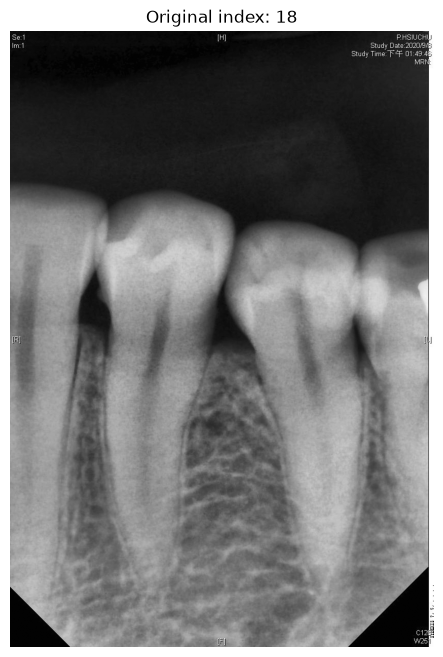

In [4]:
import matplotlib.pyplot as plt

index = 18

plt.figure(figsize=(8, 8))
plt.imshow(images[index], cmap="gray")
plt.title(f"Original index: {index}")
plt.axis("off")
plt.show()

In [5]:

print("灰階圖的資訊\n", images[18], '\n')

print("Segmentation 資訊\n", dataset_labels[18])

灰階圖的資訊
 [[ 11   3  14 ... 255 255 255]
 [ 23   3  29 ... 255 255 255]
 [  3  40   3 ... 255 255 255]
 ...
 [  3   3   3 ... 252 255 255]
 [  3   3   3 ... 255 250 255]
 [  3   3   3 ... 255 252 255]] 

Segmentation 資訊
 [[0.         0.6906485  0.5730208  0.37671515 0.73500836]
 [0.         0.36006668 0.5652292  0.47630304 0.714625  ]
 [0.         0.13516364 0.5556375  0.27032727 0.7362083 ]
 [0.         0.87497574 0.5844125  0.2500485  0.63549167]]


### ps. Bounding Box 為人工標注

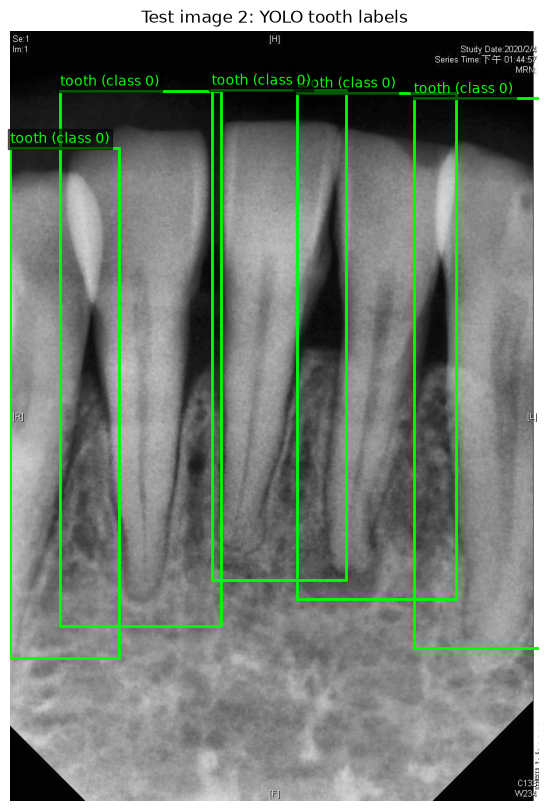

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

index = 2
image = images[index]
labels = dataset_labels[index]  # [class_id, x_center, y_center, width, height]

height, width = image.shape

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image, cmap="gray")

for class_id, x_center, y_center, box_width, box_height in labels:
    # YOLO normalized coordinates → image pixel coordinates
    x_center *= width
    y_center *= height
    box_width *= width
    box_height *= height

    x_min = x_center - box_width / 2
    y_min = y_center - box_height / 2

    box = Rectangle(
        (x_min, y_min),
        box_width,
        box_height,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
    )
    ax.add_patch(box)
    ax.text(
        x_min,
        max(y_min - 8, 0),
        f"tooth (class {int(class_id)})",
        color="lime",
        fontsize=10,
        bbox={"facecolor": "black", "alpha": 0.6, "pad": 2},
    )

ax.set_title(f"Test image {index}: YOLO tooth labels")
ax.axis("off")
plt.show()

## Step 2. 用 SegmentAnyThing Model 計算 Segmentation Mask

In [7]:
import torch
from segment_anything import SamPredictor, sam_model_registry

CHECKPOINT_PATH = PROJECT_ROOT / 'src' / 'models' / 'weights' / 'sam_vit_b_01ec64.pth'
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f'SAM checkpoint not found: {CHECKPOINT_PATH}\n'
        'Run: uv sync --extra segmentation && uv run python src/models/download_sam_weights.py'
    )

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
sam = sam_model_registry['vit_b'](checkpoint=str(CHECKPOINT_PATH))
sam.to(device=DEVICE)
sam.eval()
predictor = SamPredictor(sam)

print(f'Loaded SAM ViT-B on {DEVICE}')


Loaded SAM ViT-B on cuda


### Step 2.1：以人工 tooth box 作為 SAM prompt

每個 `dataset_labels[index]` 的 YOLO bounding box 都會轉為像素座標，並送入 SAM 產生一個牙齒 mask。`segmentation_masks[index]` 與 `sam_scores[index]` 的順序會和 `dataset_labels[index]` 完全對應。

In [8]:
def yolo_to_xyxy(yolo_label: np.ndarray, image_width: int, image_height: int) -> np.ndarray:
    """Convert [class_id, x_center, y_center, width, height] to [x1, y1, x2, y2] pixels."""
    _, x_center, y_center, box_width, box_height = yolo_label
    x_center, box_width = x_center * image_width, box_width * image_width
    y_center, box_height = y_center * image_height, box_height * image_height

    return np.array([
        max(0, x_center - box_width / 2),
        max(0, y_center - box_height / 2),
        min(image_width, x_center + box_width / 2),
        min(image_height, y_center + box_height / 2),
    ], dtype=np.float32)


def segment_teeth_with_sam(image: np.ndarray, yolo_labels: np.ndarray) -> dict:
    """Generate one SAM mask per YOLO tooth box for a single grayscale image."""
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image_height, image_width = image.shape
    boxes = np.array(
        [yolo_to_xyxy(label, image_width, image_height) for label in yolo_labels],
        dtype=np.float32,
    )

    # Calculate the image embedding once, then reuse it for every tooth box.
    with torch.inference_mode():
        predictor.set_image(image_rgb)

    masks, scores = [], []
    for box in boxes:
        with torch.inference_mode():
            candidate_masks, candidate_scores, _ = predictor.predict(
                box=box,
                multimask_output=True,
            )
        best_candidate = int(np.argmax(candidate_scores))
        masks.append(candidate_masks[best_candidate])
        scores.append(float(candidate_scores[best_candidate]))

    return {
        'image_rgb': image_rgb,
        'boxes_xyxy': boxes,
        'masks': np.asarray(masks, dtype=bool),
        'scores': np.asarray(scores, dtype=np.float32),
    }


# All four test images; set this to [2] first when using CPU for a quick trial.
target_indices = original_indices
segmentation_results = {
    index: segment_teeth_with_sam(images[index], dataset_labels[index])
    for index in target_indices
}

# Convenient CEJ-research variables. The first axis is tooth number / YOLO label row.
segmentation_masks = {index: result['masks'] for index, result in segmentation_results.items()}
sam_scores = {index: result['scores'] for index, result in segmentation_results.items()}

for index, result in segmentation_results.items():
    print(f'{index}: {len(result["masks"])} tooth masks; SAM scores = {result["scores"].round(3).tolist()}')


2: 5 tooth masks; SAM scores = [0.9869999885559082, 0.9929999709129333, 0.9710000157356262, 0.9819999933242798, 0.996999979019165]
8: 3 tooth masks; SAM scores = [0.9390000104904175, 0.9649999737739563, 0.9670000076293945]
16: 3 tooth masks; SAM scores = [0.9850000143051147, 1.0019999742507935, 0.9599999785423279]
18: 4 tooth masks; SAM scores = [0.9860000014305115, 0.9829999804496765, 0.9739999771118164, 0.9480000138282776]


### Step 2.2：檢視 mask 與 YOLO bounding box

切換 `index` 後重新執行即可查看指定 test image。半透明彩色區域為 SAM mask；青色框為人工標注的 YOLO box。

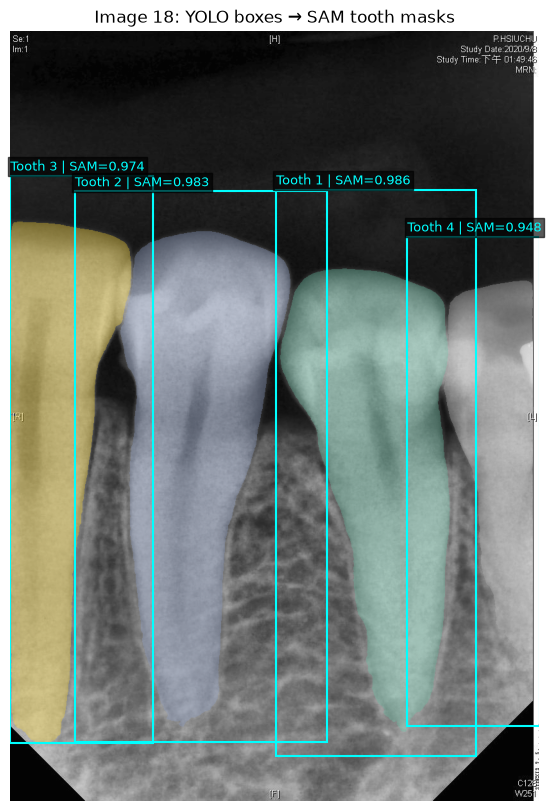

In [9]:
index = 18  # Choose one of: 2, 8, 16, 18
result = segmentation_results[index]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(result['image_rgb'])

colors = plt.cm.Set2(np.linspace(0, 1, len(result['masks'])))
for tooth_number, (mask, box, score, color) in enumerate(
    zip(result['masks'], result['boxes_xyxy'], result['scores'], colors),
    start=1,
):
    overlay = np.zeros((*mask.shape, 4))
    overlay[mask] = (*color[:3], 0.35)
    ax.imshow(overlay)

    x1, y1, x2, y2 = box
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='cyan', linewidth=1.5))
    ax.text(
        x1, max(y1 - 8, 0), f'Tooth {tooth_number} | SAM={score:.3f}',
        color='cyan', fontsize=9,
        bbox={'facecolor': 'black', 'alpha': 0.65, 'pad': 2},
    )

ax.set_title(f'Image {index}: YOLO boxes → SAM tooth masks')
ax.axis('off')
plt.show()


## 2.3 Mask 的平滑化：離散數學模型與可重跑實驗

### 2.3.1 問題定義與符號

設 $D\subset\mathbb{Z}^2$ 為有限的二維影像格點集合；SAM 所輸出的牙齒遮罩記為指示函數 $M:D\rightarrow\{0,1\}$，其中 $M(p)=1$ 表示格點 $p$ 屬於牙齒前景。對任意 $p\in D$，定義其 4-鄰域為

$$
N_4(p)=\{p\pm(1,0),\;p\pm(0,1)\}.
$$

遮罩的離散面積定義為 $A(M)=\sum_{p\in D}M(p)$。令 $p\sim_4q$ 表示 $p$ 與 $q$ 為 4-鄰居，則 4-鄰域離散周長（亦可視為二值函數的離散 total variation）定義為

$$
P_4(M)=\sum_{p\sim_4q}\lvert M(p)-M(q)\rvert.
$$

後續 CEJ 定位將利用輪廓的局部梯度、切線或等值線；因此，像素尺度的鋸齒與孤立擾動可能造成局部法向量不穩定。本節的目標並非直接宣稱某方法能提升 CEJ 定位準確度，而是在固定原始 SAM mask 下，比較不同平滑算子對其離散幾何性質的影響。

### 2.3.2 Proposition 1：Gaussian 平滑的梯度穩定性

**命題。** 設 $U=M+E$ 為受擾動的遮罩表示，其中 $E$ 為加性擾動；$G_\sigma$ 為標準差 $\sigma$ 的歸一化 Gaussian kernel。則平滑後的梯度誤差滿足

$$
\left\lVert\nabla(G_\sigma*U)-\nabla(G_\sigma*M)\right\rVert_\infty
\leq
\left\lVert\nabla G_\sigma\right\rVert_1\left\lVert E\right\rVert_\infty.
$$

**推論。** 由卷積的線性性，左側可寫為 $\lVert\nabla G_\sigma*E\rVert_\infty$；再由 Young 不等式即可得到上式。故在 soft mask $G_\sigma*M$ 上取 $0.5$ 等值線，可降低小尺度擾動傳遞至梯度估計的幅度。

**實驗意涵。** 此命題說明 Gaussian 平滑具有局部梯度穩定化的理論依據，但不等價於 CEJ 誤差必然下降。最終效益仍應以獨立的人工 CEJ 標註，量測平均邊界距離或 Hausdorff distance 後判定。

### 2.3.3 Proposition 2：形態學運算的集合論效果

**命題。** 對對稱結構元素 $B$，定義 erosion 與 dilation 分別為 $M\ominus B$、$M\oplus B$。則 opening 與 closing 為

$$
\gamma_B(M)=(M\ominus B)\oplus B,\qquad
\phi_B(M)=(M\oplus B)\ominus B.
$$

其中，opening 會移除無法容納結構元素 $B$ 的小型前景突出物；closing 則會填補無法容納 $B$ 的小型背景缺口。

**推論。** 形態學算子直接作用於前景集合，而非作用於連續強度場。因此，依序執行 opening 與 closing 時，面積與周長的變化方向不應預設：前者可能縮小集合，後者可能擴張集合，兩者的合成效果取決於局部幾何與 $B$ 的尺度。

**實驗意涵。** 本研究以面積 $A(M)$、離散周長 $P_4(M)$、改變像素數與 IoU 對此性質進行檢驗，藉以區分「移除局部雜訊」與「實質改變牙齒輪廓」兩種情況。

### 2.3.4 Proposition 3：雙向 EMA 作為可控的離散低通濾波器

**命題。** 對一維離散訊號 $x_i$，EMA 定義為

$$
y_i=\alpha x_i+(1-\alpha)y_{i-1},\qquad 0<\alpha\leq1.
$$

其輸出為過去觀測值的指數加權和，因而具低通濾波特性。

**推論。** 單向 EMA 的遞迴關係依賴掃描方向，可能使二維遮罩產生方向性偏差。為降低此效應，本文沿每一列與每一行分別執行前向及反向 EMA，並取兩者平均；所得算子為一個可由 $\alpha$ 控制平滑強度的近似零相位濾波器。

**實驗意涵。** EMA 提供與 Gaussian 卷積不同的離散低通模型：$\alpha$ 越接近 1，遮罩越接近原始結果；$\alpha$ 越小，平滑效果越強。其優劣應以相同的幾何指標和後續 CEJ 標註評估比較，而非僅憑視覺平滑程度判斷。

### 2.3.5 補充：同態濾波（Homomorphic Filtering）

同態濾波處理的是具有乘性成分的灰階影像，而不是單純的二值集合。對 X-ray 影像 $I(x,y)$，可採用影像形成模型

$$
I(x,y)=L(x,y)R(x,y),
$$

其中 $L$ 表示緩慢變化的照明／背景成分，$R$ 表示局部反射、組織結構與邊緣等細節。取對數後，乘性模型轉為加性模型：

$$
\log(I+\varepsilon)=\log(L+\varepsilon)+\log(R+\varepsilon).
$$

在 Fourier domain 中使用頻率響應 $H(u,v)$ 抑制低頻照明、保留高頻結構，例如

$$
H(u,v)=\left(\gamma_H-\gamma_L\right)
\left[1-\exp\left(-c\frac{D(u,v)^2}{D_0^2}\right)\right]+\gamma_L,
$$

其中 $D(u,v)$ 是頻率平面中心的距離，$D_0$ 控制 cutoff scale，通常取 $\gamma_L<1$、$\gamma_H>1$。反變換並取指數後得到

$$
I_{\mathrm{HF}}(x,y)=
\exp\left\{\mathcal{F}^{-1}\left[H(u,v)\,\mathcal{F}\{\log(I+\varepsilon)\}\right]\right\}.
$$

![Homomorphic filtering reference](../references/homomorphic.png)

**Proposition 4（同態濾波的適用範圍）。** 若影像的照明成分主要集中在低頻，而牙齒邊界等結構主要包含較高頻率，則適當選擇 $D_0$、$\gamma_L$ 與 $\gamma_H$，可在降低背景不均勻的同時提升局部結構對比。

**限制與本研究的使用方式。** 同態濾波不是二值 mask 的直接平滑器：對 $M\in\{0,1\}$ 直接取 $\log M$ 會遇到 $\log 0$，即使加入 $\varepsilon$，二值遮罩也沒有足夠的灰階資訊可供照明／反射分離。因此，本研究不把同態濾波納入 `segmentation_masks` 的直接替代方法；較合理的實驗位置是：先對原始 X-ray 或牙齒 ROI 做同態增強，再送入 SAM，最後仍以 mask 的 $A(M)$、$P_4(M)$、IoU 與人工 CEJ 標註評估其影響。


In [10]:
# 共用的離散量測函式：只接受二值 mask，避免不同方法的 soft 值直接混比。
def mask_metrics(mask: np.ndarray) -> dict:
    """Return area and 4-neighbour boundary metrics for a binary mask."""
    binary = np.asarray(mask, dtype=bool)
    padded = np.pad(binary.astype(np.int8), 1, mode="constant")

    # Each foreground/background interface is counted once, including image borders.
    perimeter_4 = int(
        np.abs(np.diff(padded, axis=0)).sum()
        + np.abs(np.diff(padded, axis=1)).sum()
    )
    area = int(binary.sum())
    compactness_4 = float(4 * np.pi * area / perimeter_4**2) if perimeter_4 else np.nan
    return {
        "area_px": area,
        "perimeter_4_px": perimeter_4,
        "total_variation_4": perimeter_4,
        "compactness_4": compactness_4,
    }


def binary_iou(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    """IoU on D; 1.0 when both masks are empty."""
    a, b = np.asarray(mask_a, dtype=bool), np.asarray(mask_b, dtype=bool)
    union = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum() / union) if union else 1.0


def changed_pixel_count(mask_a: np.ndarray, mask_b: np.ndarray) -> int:
    return int(np.logical_xor(mask_a, mask_b).sum())


### 量測模型：面積、離散周長與 IoU

對二值 mask，$A(M)$ 直接以 True 像素數量表示；$P_4(M)$ 以 4-鄰域前景／背景交界邊的數目表示，因此 $P_4$ 越小通常代表輪廓的像素級折線越少。IoU 衡量平滑後集合與原集合的重疊程度。這些是**幾何代理指標**，不是 CEJ accuracy。

### Method 1：雙向 EMA

先把 $M$ 轉為 $[0,1]$ 的浮點陣列。沿每一列與每一行分別計算前向、反向 EMA 後平均，再以 $0.5$ 閾值二值化。參數 $\alpha$ 越接近 1，輸出越接近原始 mask；越小則平滑越強。

In [11]:
def _ema_1d(values: np.ndarray, alpha: float) -> np.ndarray:
    """Causal EMA: y[i] = alpha*x[i] + (1-alpha)*y[i-1]."""
    values = np.asarray(values, dtype=np.float32)
    output = np.empty_like(values)
    output[0] = values[0]
    for i in range(1, len(values)):
        output[i] = alpha * values[i] + (1 - alpha) * output[i - 1]
    return output


def _bidirectional_ema_1d(values: np.ndarray, alpha: float) -> np.ndarray:
    """Average forward and backward EMA to remove a preferred scan direction."""
    forward = _ema_1d(values, alpha)
    backward = _ema_1d(values[::-1], alpha)[::-1]
    return (forward + backward) / 2


def ema_smooth_mask(
    mask: np.ndarray, alpha: float = 0.65, threshold: float = 0.65
) -> tuple[np.ndarray, np.ndarray]:
    """Return (soft_mask, thresholded_mask) from separable bidirectional EMA."""
    if not 0 < alpha <= 1:
        raise ValueError("alpha must be in (0, 1].")
    soft = np.asarray(mask, dtype=np.float32)
    for axis in (0, 1):
        soft = np.apply_along_axis(_bidirectional_ema_1d, axis, soft, alpha)
    return soft, soft >= threshold


### Method 2：Gaussian blur + $0.5$ 等值線

離散卷積 $S_\sigma=M*G_\sigma$ 以半徑約 $3\sigma$ 的 kernel 實作。最後取 $\{p:S_\sigma(p)\geq0.5\}$，即以 $0.5$ 等值線重新定義邊界。$\sigma$ 的單位是 pixel。

In [12]:
def gaussian_smooth_mask(
    mask: np.ndarray, sigma: float = 1.0, threshold: float = 0.5
) -> tuple[np.ndarray, np.ndarray]:
    """Return (Gaussian soft mask, its thresholded 0.5-level-set mask)."""
    if sigma <= 0:
        raise ValueError("sigma must be positive.")
    kernel_size = int(2 * np.ceil(3 * sigma) + 1)  # odd; captures about 99.7% in 1-D
    soft = cv2.GaussianBlur(
        np.asarray(mask, dtype=np.float32),
        (kernel_size, kernel_size),
        sigmaX=sigma,
        sigmaY=sigma,
        borderType=cv2.BORDER_REFLECT101,
    )
    return soft, soft >= threshold


### Method 3：disk opening → closing

令 $B_r=\{(i,j)\in\mathbb{Z}^2:i^2+j^2\le r^2\}$。先 opening 再 closing：前者刪除小於半徑 $r$ 的前景尖刺，後者填補同尺度背景缺口。這個方法保留二值集合的語意，與 EMA／Gaussian 的 soft field 模型不同。

In [13]:
def morphology_open_close_mask(mask: np.ndarray, radius: int = 1) -> np.ndarray:
    """Apply disk-like opening then closing; return a binary mask."""
    if radius < 1:
        raise ValueError("radius must be a positive integer.")
    size = 2 * int(radius) + 1
    structuring_element = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))
    binary_u8 = np.asarray(mask, dtype=np.uint8)
    opened = cv2.morphologyEx(binary_u8, cv2.MORPH_OPEN, structuring_element)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, structuring_element)
    return closed.astype(bool)


### 實驗：在同一顆牙齒上檢驗命題

此 cell 會先將三種方法套用到所有 `segmentation_masks`，再選擇一顆牙齒顯示。表格中 `ΔP4<0` 是輪廓複雜度下降的可觀測證據；IoU 高則表示平滑未大幅改變原集合。請改動 `experiment_index`、`experiment_tooth_number` 或參數後重新執行。

Image 18, tooth 2: mask comparison
method                          area (px)       Δarea        P4        ΔP4        IoU
Original SAM                       129987          +0      2126         +0   1.000000
Bidirectional EMA (α=0.3)          128644       -1343      2090        -36   0.989653
Gaussian (σ=1.0, t=0.5)            129987          +0      2122         -4   0.999985
Open→close (r=1)                   129985          -2      2126         +0   0.999985

命題檢驗（幾何代理指標，不是 CEJ ground-truth accuracy）：
- Bidirectional EMA (α=0.3): P4 是否不增加 → 支持; changed=1345 px (1.0347%)
- Gaussian (σ=1.0, t=0.5): P4 是否不增加 → 支持; changed=2 px (0.0015%)
- Open→close (r=1): P4 是否不增加 → 支持; changed=2 px (0.0015%)


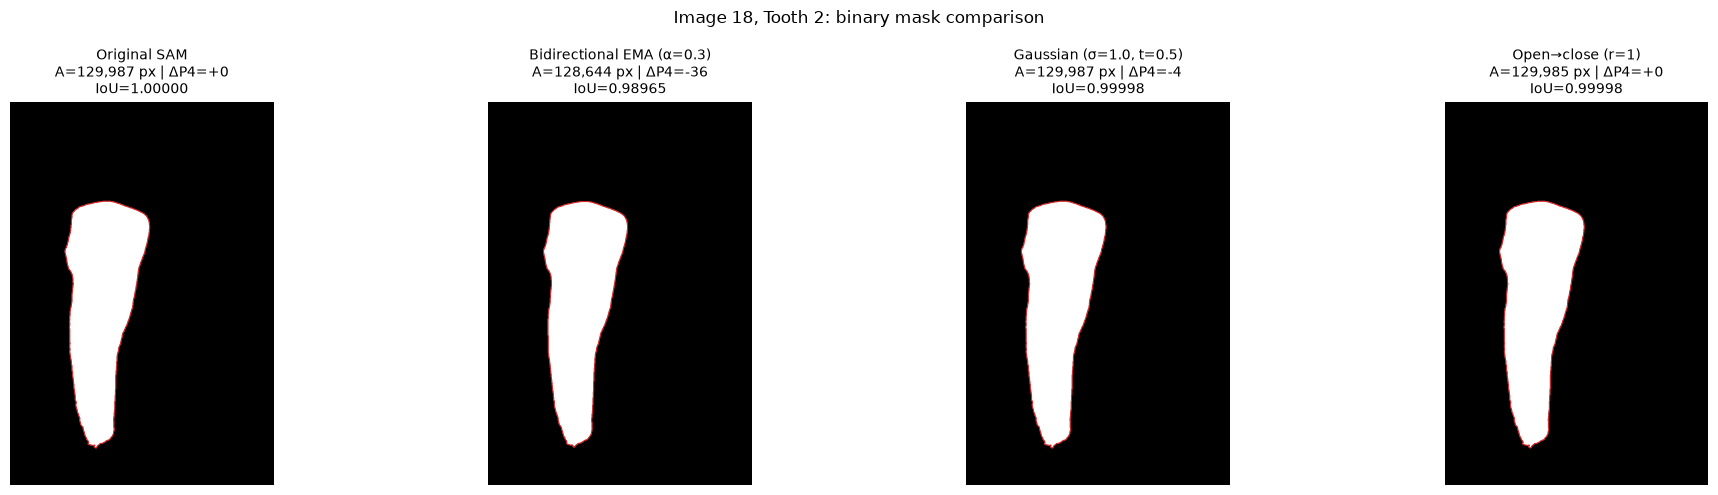

In [14]:
# Parameters are in pixels except EMA alpha.  Change them before comparing again.
EMA_ALPHA = 0.3
GAUSSIAN_SIGMA = 1.0
MORPH_RADIUS = 1

# Keep results for every test image so later CEJ/PCA cells can choose a method explicitly.
ema_soft_masks = {}
ema_smoothed_masks = {}
gaussian_soft_masks = {}
smoothed_segmentation_masks = {}
morphology_cleaned_masks = {}

for image_index, masks in segmentation_masks.items():
    ema_pairs = [ema_smooth_mask(mask, alpha=EMA_ALPHA) for mask in masks]
    gaussian_pairs = [gaussian_smooth_mask(mask, sigma=GAUSSIAN_SIGMA) for mask in masks]
    ema_soft_masks[image_index] = np.asarray([soft for soft, _ in ema_pairs])
    ema_smoothed_masks[image_index] = np.asarray([binary for _, binary in ema_pairs], dtype=bool)
    gaussian_soft_masks[image_index] = np.asarray([soft for soft, _ in gaussian_pairs])
    smoothed_segmentation_masks[image_index] = np.asarray(
        [binary for _, binary in gaussian_pairs], dtype=bool
    )
    morphology_cleaned_masks[image_index] = np.asarray(
        [morphology_open_close_mask(mask, radius=MORPH_RADIUS) for mask in masks], dtype=bool
    )

experiment_index = 18
experiment_tooth_number = 2  # one-based, consistent with the labels shown above
experiment_tooth_idx = experiment_tooth_number - 1
raw_mask = segmentation_masks[experiment_index][experiment_tooth_idx]

method_masks = {
    "Original SAM": raw_mask,
    f"Bidirectional EMA (α={EMA_ALPHA})": ema_smoothed_masks[experiment_index][experiment_tooth_idx],
    f"Gaussian (σ={GAUSSIAN_SIGMA}, t=0.5)": smoothed_segmentation_masks[experiment_index][experiment_tooth_idx],
    f"Open→close (r={MORPH_RADIUS})": morphology_cleaned_masks[experiment_index][experiment_tooth_idx],
}

reference_metrics = mask_metrics(raw_mask)
comparison_rows = []
for method_name, method_mask in method_masks.items():
    metrics = mask_metrics(method_mask)
    changed = changed_pixel_count(raw_mask, method_mask)
    comparison_rows.append({
        "method": method_name,
        **metrics,
        "area_delta_px": metrics["area_px"] - reference_metrics["area_px"],
        "perimeter_delta_px": metrics["perimeter_4_px"] - reference_metrics["perimeter_4_px"],
        "changed_px": changed,
        "changed_percent": 100 * changed / reference_metrics["area_px"],
        "iou_to_original": binary_iou(raw_mask, method_mask),
    })

print(f"Image {experiment_index}, tooth {experiment_tooth_number}: mask comparison")
print("{:<30} {:>10} {:>11} {:>9} {:>10} {:>10}".format(
    "method", "area (px)", "Δarea", "P4", "ΔP4", "IoU"
))
for row in comparison_rows:
    print("{:<30} {:>10d} {:>+11d} {:>9d} {:>+10d} {:>10.6f}".format(
        row["method"], row["area_px"], row["area_delta_px"],
        row["perimeter_4_px"], row["perimeter_delta_px"], row["iou_to_original"],
    ))

print("\n命題檢驗（幾何代理指標，不是 CEJ ground-truth accuracy）：")
for row in comparison_rows[1:]:
    perimeter_test = "支持" if row["perimeter_delta_px"] <= 0 else "未支持"
    print(
        f"- {row['method']}: P4 是否不增加 → {perimeter_test}; "
        f"changed={row['changed_px']} px ({row['changed_percent']:.4f}%)"
    )

fig, axes = plt.subplots(1, len(method_masks), figsize=(5 * len(method_masks), 5))
for ax, row in zip(axes, comparison_rows):
    mask = method_masks[row["method"]]
    ax.imshow(mask, cmap="gray", vmin=0, vmax=1)
    ax.contour(mask.astype(float), levels=[0.5], colors="tab:red", linewidths=0.8)
    ax.set_title(
        f"{row['method']}\nA={row['area_px']:,} px | ΔP4={row['perimeter_delta_px']:+d}\nIoU={row['iou_to_original']:.5f}",
        fontsize=10,
    )
    ax.axis("off")
fig.suptitle(f"Image {experiment_index}, Tooth {experiment_tooth_number}: binary mask comparison", y=0.98)
plt.tight_layout()
plt.show()

# Deliberate default: PCA is global and should not silently depend on smoothing.
pca_masks = segmentation_masks


> Conclusions

平滑比較已產生於 `comparison_rows`：每一列都包含面積（`area_px`）、面積差、4-鄰域周長／總變差、改變像素數與 IoU。各方法的遮罩圖會由最後一個實驗 cell 輸出；全部影像的結果保存在 `ema_smoothed_masks`、`smoothed_segmentation_masks` 與 `morphology_cleaned_masks`。

目前 `pca_masks` 仍刻意指向原始 `segmentation_masks`，避免 PCA 結果被某組平滑超參數默默改寫。若後續任務是輪廓切線、曲率或 CEJ 邊界，建議先固定參數，再用人工 CEJ 標註比較平均邊界距離／Hausdorff distance，而不是只依據 $P_4$ 最小來選方法。

### 2.3.5 補充：同態濾波（Homomorphic Filtering）

[Homomorphic Filter](../references/homomorphic.png)

同態濾波主要用於處理具有乘性照明與反射成分的灰階影像，與 Gaussian 或 EMA 的二值遮罩平滑不同。

對 X-ray 影像 $I(x,y)$，可使用影像形成模型：

$$
I(x,y)=L(x,y)R(x,y),
$$

其中：

- $L(x,y)$ 表示緩慢變化的照明或背景成分；
- $R(x,y)$ 表示牙齒結構、組織細節與邊緣等局部反射成分。

由於照明與反射是乘法關係，先取對數即可轉換為加法：

$$
\log(I(x,y)+\varepsilon)
=
\log(L(x,y)+\varepsilon)
+
\log(R(x,y)+\varepsilon),
$$

其中 $\varepsilon>0$ 用於避免影像像素為零時的數值問題。

在 Fourier domain 中，使用頻率響應函數 $H(u,v)$ 抑制低頻照明成分，並保留或增強高頻結構：

$$
H(u,v)
=
(\gamma_H-\gamma_L)
\left[
1-\exp\left(
-c\frac{D(u,v)^2}{D_0^2}
\right)
\right]
+\gamma_L,
$$

其中：

- $D(u,v)$ 是頻率座標 $(u,v)$ 到頻率中心的距離；
- $D_0$ 是 cutoff frequency，用來控制低頻與高頻的分界；
- $\gamma_L<1$，控制低頻成分的衰減程度；
- $\gamma_H>1$，控制高頻結構的增強程度；
- $c$ 控制濾波器過渡區域的斜率。

經過 Fourier filtering 後，再反變換並取指數，可得到增強後的影像：

$$
I_{\mathrm{HF}}(x,y)
=
\exp
\left\{
\mathcal{F}^{-1}
\left[
H(u,v)
\mathcal{F}
\left\{
\log(I(x,y)+\varepsilon)
\right\}
\right]
\right\}.
$$

**Proposition 4（同態濾波的適用條件）**

若影像中的照明或背景不均勻主要集中於低頻，而牙齒邊界與局部結構主要包含較高頻率，則適當選擇 $D_0$、$\gamma_L$ 與 $\gamma_H$，可以在抑制背景不均勻的同時增強牙齒邊界對比。

**推論**

同態濾波的核心作用不是直接平滑 mask，而是先改善原始灰階影像的照明一致性與局部對比。若影像模型成立，經過同態增強後，SAM 可能更容易辨識牙齒邊界。

**限制**

同態濾波不適合直接套用在二值 mask 上。對於

$$
M(x,y)\in\{0,1\},
$$

直接計算 $\log M$ 會遇到 $\log 0$；即使加入 $\varepsilon$，二值 mask 也缺乏足夠的灰階資訊來分離照明與反射成分。

因此，本研究較合理的流程為：

$$
\text{原始 X-ray}
\rightarrow
\text{同態濾波}
\rightarrow
\text{SAM segmentation}
\rightarrow
\text{mask 平滑}
\rightarrow
\text{CEJ 定位}.
$$

同態濾波的效果應以後續 SAM mask 的面積 $A(M)$、離散周長 $P_4(M)$、IoU，以及人工 CEJ 標註下的平均邊界距離或 Hausdorff distance 進行評估，而不應僅依據影像視覺對比判定。

## Step 3. PCA calculate main axis

### Step 3.1 統整目前已有的變數及資訊
- 拿了 YOLO 格式的 Test Set，有人工標注的 Bounding Box Labels
- 用沒微調過的 SegmentAnyThing 生成 Mask

參數總整理：

Locating Tooth Position:
- `index`：影像編號，例如 `18`。 (共有 [2, 8, 16, 18]在此 notebook)
- `images[index]`：該張測試 X-ray 灰階影像，shape 為 `(H, W)`。
- `dataset_labels[index]`：人工標註的 YOLO bounding boxes，shape 為 `(牙齒數, 5)`。
- `tooth_number`：要選擇的牙齒順序，從 `1` 開始。
- `tooth_idx`：Python 陣列索引，為 `tooth_number - 1`。
- `tooth_label`：該牙齒的 YOLO 標註，格式為 `[class_id, x_center, y_center, width, height]`，座標為 normalized 值。
- `tooth_box`：轉換後的像素級 bounding box，格式為 `[x1, y1, x2, y2]`。

Segmentation:
- `sam`：未針對牙齒微調的官方 SAM ViT-B 模型。
- `predictor`：SAM 的預測器，以 YOLO box 作為 segmentation prompt。
- `segmentation_results[index]`：該影像全部牙齒的 SAM 分割結果。
- `tooth_mask`：指定牙齒的二值 mask，shape 為 `(H, W)`；`True` 表示牙齒區域。
- `tooth_score`：SAM 對該 mask 的 confidence score。
- `segmentation_masks[index]`：該影像全部牙齒的 mask，shape 為 `(牙齒數, H, W)`。
- `sam_scores[index]`：該影像各牙齒的 SAM confidence scores。

In [15]:
index = 18          # 影像編號
tooth_number = 2    # 顯示用牙齒編號，從 1 開始
tooth_idx = tooth_number - 1

result = segmentation_results[index]

tooth_mask = result["masks"][tooth_idx]       # shape: (H, W), dtype: bool
tooth_box = result["boxes_xyxy"][tooth_idx]   # [x1, y1, x2, y2]
tooth_score = result["scores"][tooth_idx]     # SAM confidence
tooth_label = dataset_labels[index][tooth_idx]  # [class_id, xc, yc, w, h]

print(f"mask shape: {tooth_mask.shape}")
print(f"mask area: {tooth_mask.sum()} pixels")
print(f"YOLO box: {tooth_box}")
print(f"SAM score: {tooth_score:.3f}")
print(f"mask 前景座標 (y, x):", np.where(tooth_mask))

mask shape: (1200, 825)
mask area: 129987 pixels
YOLO box: [ 100.58002  249.50003  493.53003 1107.05   ]
SAM score: 0.983
mask 前景座標 (y, x): (array([ 312,  312,  312, ..., 1083, 1083, 1083], shape=(129987,)), array([290, 291, 292, ..., 268, 269, 270], shape=(129987,)))


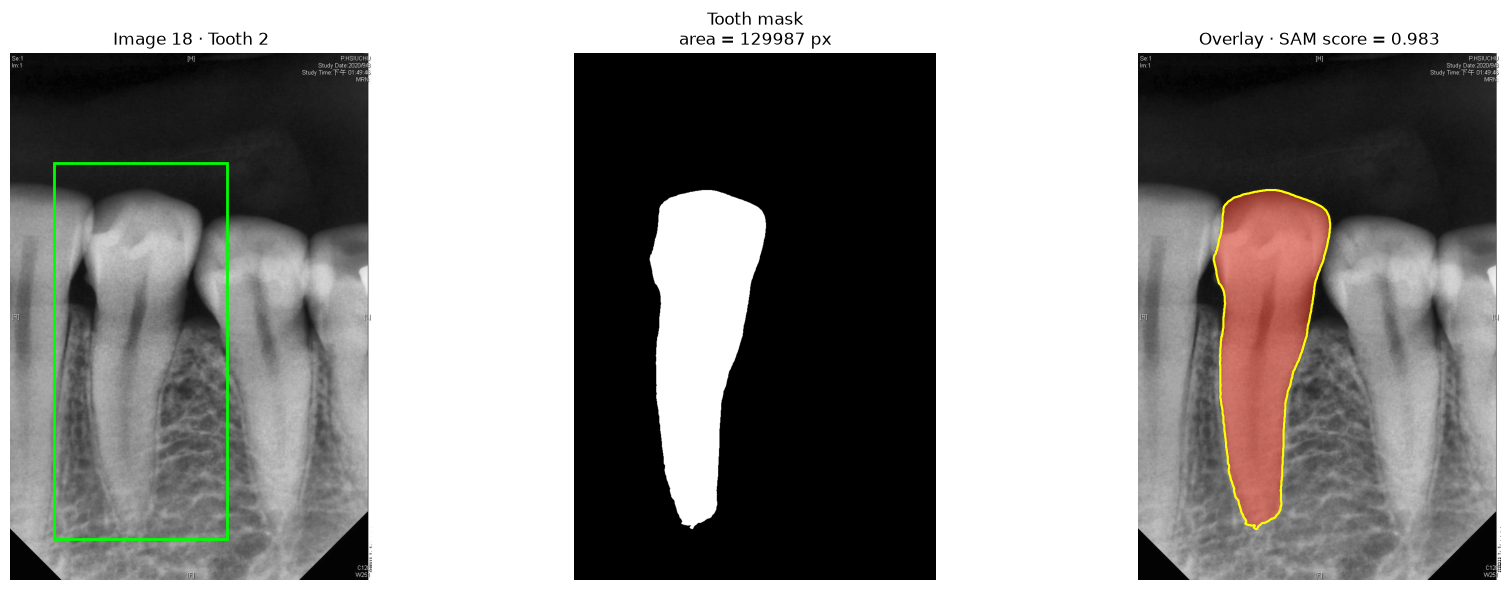

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

image_rgb = result["image_rgb"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 原始影像與 YOLO box
axes[0].imshow(image_rgb)
x1, y1, x2, y2 = tooth_box
axes[0].add_patch(
    Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        fill=False, edgecolor="lime", linewidth=2,
    )
)
axes[0].set_title(f"Image {index} · Tooth {tooth_number}")
axes[0].axis("off")

# 2. 只有這顆牙齒的二值 mask
axes[1].imshow(tooth_mask, cmap="gray")
axes[1].set_title(f"Tooth mask\narea = {tooth_mask.sum()} px")
axes[1].axis("off")

# 3. 原圖與 mask 疊圖
axes[2].imshow(image_rgb)

overlay = np.zeros((*tooth_mask.shape, 4))
overlay[tooth_mask] = (1.0, 0.2, 0.1, 0.45)  # RGBA：紅色、45% 透明
axes[2].imshow(overlay)

axes[2].contour(tooth_mask, levels=[0.5], colors="yellow", linewidths=1.5)
axes[2].set_title(f"Overlay · SAM score = {tooth_score:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Step 3.2 以下用 images[18] 為範例用 PCA 計算主軸
利用 EMA Filter 後的 Mask

PCA input: EMA-smoothed mask | image 18, tooth 2
foreground pixels: 128,644
centroid (x, y): [286.36 635.19]
principal axis (x, y): [-0.0796  0.9968]
eigenvalues: [ 3106.19 41638.82]
principal variance explained: 93.06%


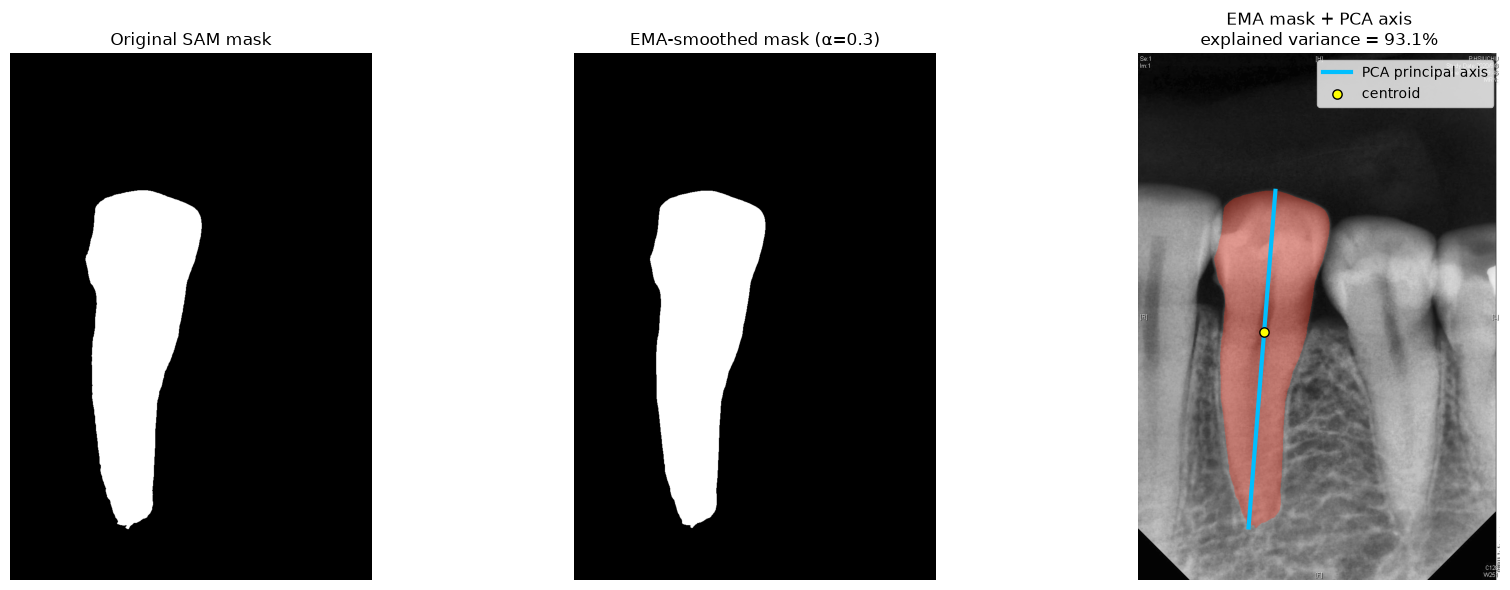

In [17]:
# PCA 的輸入明確使用 Step 2.3 產生的 EMA 二值化 mask，而非原始 SAM mask。
# 若要重跑 image 18 的範例，先在 Step 3.1 設定 index = 18、tooth_number = 2。
pca_input_mask = ema_smoothed_masks[index][tooth_idx]
pca_ys, pca_xs = np.nonzero(pca_input_mask)
if len(pca_xs) < 3:
    raise ValueError("EMA-smoothed mask needs at least three foreground pixels for PCA.")

# PCA 點的座標順序固定為 (x, y)；np.nonzero 回傳的順序則是 (y, x)。
pca_points_xy = np.column_stack((pca_xs, pca_ys)).astype(np.float64)
pca_centroid_xy = pca_points_xy.mean(axis=0)
pca_centered_xy = pca_points_xy - pca_centroid_xy
pca_covariance = np.cov(pca_centered_xy, rowvar=False)
pca_eigenvalues, pca_eigenvectors = np.linalg.eigh(pca_covariance)

# eigh 的 eigenvalue 由小到大排列；最後一個 eigenvector 即最長的主軸方向。
principal_axis_xy = pca_eigenvectors[:, -1]
principal_axis_xy /= np.linalg.norm(principal_axis_xy)
# PCA 的軸正負號本來不唯一。固定成由影像上方指向下方，讓後續 crown/root 判讀可重現。
if principal_axis_xy[1] < 0:
    principal_axis_xy *= -1
minor_axis_xy = pca_eigenvectors[:, 0]
if minor_axis_xy[0] < 0:
    minor_axis_xy *= -1

total_variance = float(pca_eigenvalues.sum())
if total_variance <= 0:
    raise ValueError("EMA-smoothed mask has no spatial variance; its principal axis is undefined.")
principal_variance_ratio = float(pca_eigenvalues[-1] / total_variance)

# 把所有前景像素投影到主軸，投影的最小／最大值定義主軸在 mask 內的兩個端點。
pca_projection = pca_centered_xy @ principal_axis_xy
axis_top_xy = pca_centroid_xy + pca_projection.min() * principal_axis_xy
axis_bottom_xy = pca_centroid_xy + pca_projection.max() * principal_axis_xy

pca_result = {
    'mask': pca_input_mask,
    'centroid_xy': pca_centroid_xy,
    'principal_axis_xy': principal_axis_xy,
    'minor_axis_xy': minor_axis_xy,
    'eigenvalues': pca_eigenvalues,
    'principal_variance_ratio': principal_variance_ratio,
    'axis_top_xy': axis_top_xy,
    'axis_bottom_xy': axis_bottom_xy,
}

print(f'PCA input: EMA-smoothed mask | image {index}, tooth {tooth_number}')
print(f'foreground pixels: {len(pca_points_xy):,}')
print(f'centroid (x, y): {pca_centroid_xy.round(2)}')
print(f'principal axis (x, y): {principal_axis_xy.round(4)}')
print(f'eigenvalues: {pca_eigenvalues.round(2)}')
print(f'principal variance explained: {principal_variance_ratio:.2%}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(tooth_mask, cmap='gray')
axes[0].set_title('Original SAM mask')

axes[1].imshow(pca_input_mask, cmap='gray')
axes[1].set_title(f'EMA-smoothed mask (α={EMA_ALPHA})')

axes[2].imshow(image_rgb)
ema_overlay = np.zeros((*pca_input_mask.shape, 4))
ema_overlay[pca_input_mask] = (1.0, 0.2, 0.1, 0.35)
axes[2].imshow(ema_overlay)
axes[2].plot(
    [axis_top_xy[0], axis_bottom_xy[0]],
    [axis_top_xy[1], axis_bottom_xy[1]],
    color='deepskyblue', linewidth=3, label='PCA principal axis',
)
axes[2].scatter(*pca_centroid_xy, s=45, color='yellow', edgecolor='black', zorder=3, label='centroid')
axes[2].set_title(f'EMA mask + PCA axis\nexplained variance = {principal_variance_ratio:.1%}')
axes[2].legend(loc='upper right')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3.3  X Ray 特性之牙齒顏色差異

假設：在 X 光片下，基於物體密度不同，電子穿透率不同導致顏色差異。
牙齒可以分成牙冠及牙根，我的目標是要找 CEJ (Cemen-Enamel Junction)，牙冠的珐瑯質密度較高理論上應該較白。牙根則是由牙骨質包裹著象牙質。

### 3.3.1 演算法：以放射不透光性建立連續 CEJ 候選曲線

不直接用全域灰階閾值：不同 X 光的曝光、增益與背景會改變整體亮度。先由 Step 3.2 的 tooth mask 取得 PCA 主軸，並將 ROI 重取樣為 $(s,t)$ 座標；$t$ 是牙冠到牙根方向，$s$ 是橫向方向。對每一條 $s$ column，將平滑後的灰階強度 $I(s,t)$ 微分：

$$E(s,t)=\max\left(-\frac{\partial I(s,t)}{\partial t},0\right).$$

這是「由較白的琺瑯質區往牙根移動時亮度下降」的局部證據。最後以 dynamic programming 在搜尋帶內最大化 $E$，同時懲罰相鄰 column 的高度跳動，得到單一平滑曲線，而不是把每個 column 各自最大的雜訊邊緣串起來。搜尋時排除 tooth mask 的外輪廓，以免把牙齒邊界誤當 CEJ。

自動判斷 crown 端只是一項方便的啟發式（端點的第 85 百分位亮度加上少量寬度資訊）；請在 overlay 檢視其方向。若原始影像是黑白反相（例如 DICOM 的 `MONOCHROME1`），必須令 `white_is_high=False`。修復體、齲齒、重疊牙與曝光偽影都可能產生更強的邊緣，因此產出應稱為 **CEJ candidate**，並以獨立人工 CEJ 標註量測誤差。



Crown endpoint: low_t | endpoint scores: {'low_t': 205.7010955810547, 'high_t': 164.53738403320312} | mean CEJ edge score: 1.205


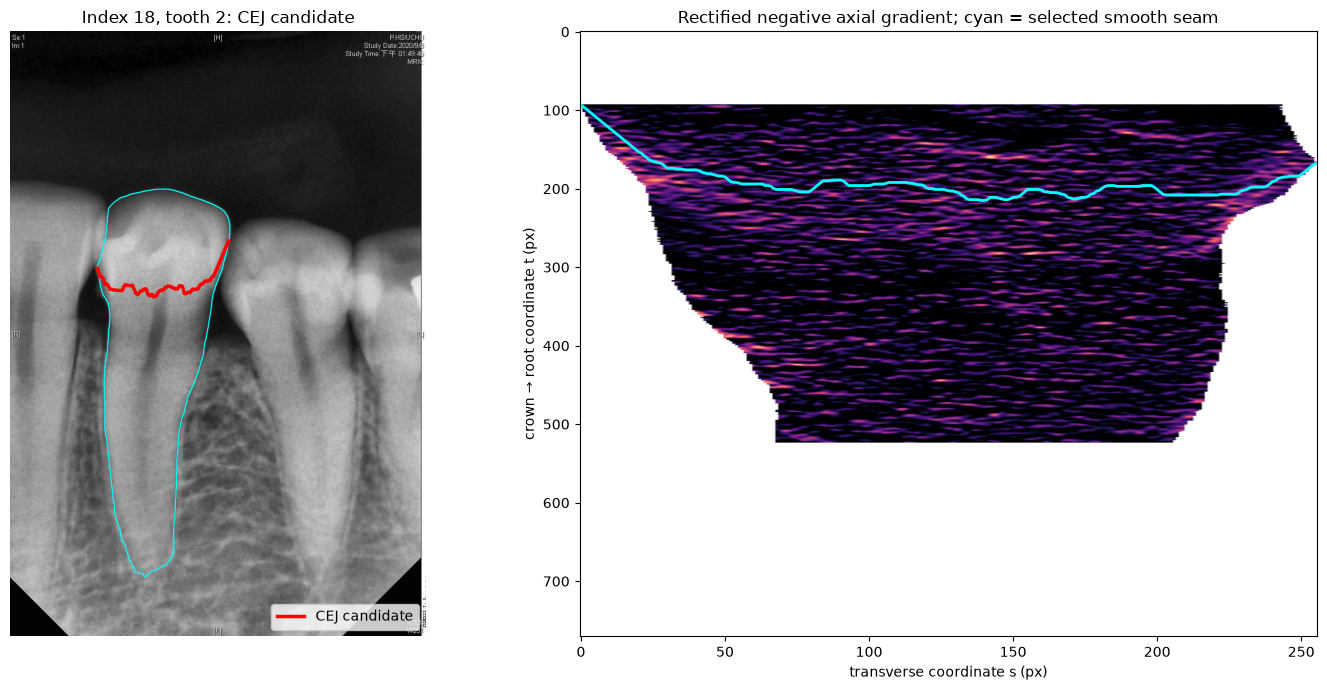

In [19]:
# CEJ candidate = a continuous high-to-low radiopacity transition from crown to root.
# Important: this is a candidate generator, not a CEJ ground truth label.  A restoration,
# caries, overlap with another tooth, or an exposure artefact can produce a stronger edge.

def _tooth_pca(mask: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return centroid, long axis and transverse axis in (x, y) image coordinates."""
    ys, xs = np.nonzero(mask)
    if len(xs) < 3:
        raise ValueError('tooth mask needs at least three foreground pixels.')
    points = np.column_stack((xs, ys)).astype(np.float32)
    centroid = points.mean(axis=0)
    _, _, vh = np.linalg.svd(points - centroid, full_matrices=False)
    long_axis = vh[0] / np.linalg.norm(vh[0])
    transverse_axis = np.array([-long_axis[1], long_axis[0]], dtype=np.float32)
    return centroid, long_axis, transverse_axis


def _longest_true_run(values: np.ndarray) -> tuple[int, int]:
    """Return [start, stop) of the longest contiguous True run."""
    padded = np.r_[False, np.asarray(values, dtype=bool), False]
    changes = np.flatnonzero(padded[1:] != padded[:-1])
    starts, stops = changes[::2], changes[1::2]
    if not len(starts):
        raise ValueError('No valid CEJ candidate columns.')
    best = np.argmax(stops - starts)
    return int(starts[best]), int(stops[best])


def _maximum_score_seam(
    score: np.ndarray, allowed: np.ndarray, max_step_px: int = 3, smoothness: float = 0.35
) -> np.ndarray:
    """Dynamic-programming seam: maximise edge score while penalising sharp bends."""
    height, width = score.shape
    dp = np.full((height, width), -np.inf, dtype=np.float32)
    parent = np.full((height, width), -1, dtype=np.int32)
    dp[allowed[:, 0], 0] = score[allowed[:, 0], 0]

    for column in range(1, width):
        for row in np.flatnonzero(allowed[:, column]):
            lo, hi = max(0, row - max_step_px), min(height, row + max_step_px + 1)
            previous = dp[lo:hi, column - 1]
            offsets = np.arange(lo, hi) - row
            transition = previous - smoothness * (offsets / max_step_px) ** 2
            source = int(np.argmax(transition))
            if np.isfinite(transition[source]):
                dp[row, column] = score[row, column] + transition[source]
                parent[row, column] = lo + source

    seam = np.empty(width, dtype=np.int32)
    seam[-1] = int(np.argmax(dp[:, -1]))
    if not np.isfinite(dp[seam[-1], -1]):
        raise ValueError('CEJ path is disconnected; adjust the search band or mask.')
    for column in range(width - 1, 0, -1):
        seam[column - 1] = parent[seam[column], column]
    return seam


def locate_cej_by_radiopacity(
    image: np.ndarray,
    tooth_mask: np.ndarray,
    crown_end: str = 'auto',
    white_is_high: bool = True,
    search_range: tuple[float, float] = (0.12, 0.68),
    max_step_px: int = 3,
) -> dict:
    """
    Estimate a CEJ curve from an X-ray and one tooth mask.

    The mask is rectified into PCA coordinates: t follows crown -> root and s is
    transverse.  In each s column, -dI/dt is the enamel-to-root edge evidence.
    Dynamic programming then chooses one smooth curve rather than independent peaks.
    crown_end can be 'auto', 'low_t', or 'high_t'; verify the auto orientation visually.
    Set white_is_high=False for inverse-polarity source images (e.g. MONOCHROME1).
    """
    if image.ndim != 2 or tooth_mask.shape != image.shape:
        raise ValueError('image and tooth_mask must be same-size 2-D arrays.')
    if not (0 <= search_range[0] < search_range[1] <= 1):
        raise ValueError('search_range must satisfy 0 <= start < stop <= 1.')

    mask = np.asarray(tooth_mask, dtype=bool)
    working_image = image.astype(np.float32)
    if not white_is_high:
        working_image = working_image.max() - working_image
    centroid, long_axis, transverse_axis = _tooth_pca(mask)
    ys, xs = np.nonzero(mask)
    points = np.column_stack((xs, ys)).astype(np.float32)
    long_projection = (points - centroid) @ long_axis

    # Decide which PCA endpoint is crown.  Enamel makes the endpoint's upper quantile
    # brighter; width is only a small tie-breaker because crowns are usually broader.
    endpoint_width = 0.22 * (long_projection.max() - long_projection.min())
    low_pixels = points[long_projection <= long_projection.min() + endpoint_width]
    high_pixels = points[long_projection >= long_projection.max() - endpoint_width]
    def endpoint_score(endpoint_pixels: np.ndarray) -> float:
        ex, ey = endpoint_pixels[:, 0].astype(int), endpoint_pixels[:, 1].astype(int)
        brightness = np.percentile(working_image[ey, ex], 85)
        width = np.percentile(np.abs((endpoint_pixels - centroid) @ transverse_axis), 90)
        return float(brightness + 0.10 * width)
    low_score, high_score = endpoint_score(low_pixels), endpoint_score(high_pixels)
    if crown_end == 'auto':
        crown_end = 'low_t' if low_score >= high_score else 'high_t'
    if crown_end not in {'low_t', 'high_t'}:
        raise ValueError("crown_end must be 'auto', 'low_t', or 'high_t'.")
    root_axis = long_axis if crown_end == 'low_t' else -long_axis

    root_projection = (points - centroid) @ root_axis
    transverse_projection = (points - centroid) @ transverse_axis
    t_values = np.arange(np.floor(root_projection.min()), np.ceil(root_projection.max()) + 1)
    s_values = np.arange(np.floor(transverse_projection.min()), np.ceil(transverse_projection.max()) + 1)
    s_grid, t_grid = np.meshgrid(s_values, t_values)
    map_x = (centroid[0] + s_grid * transverse_axis[0] + t_grid * root_axis[0]).astype(np.float32)
    map_y = (centroid[1] + s_grid * transverse_axis[1] + t_grid * root_axis[1]).astype(np.float32)
    image_grid = cv2.remap(working_image, map_x, map_y, cv2.INTER_LINEAR)
    mask_grid = cv2.remap(mask.astype(np.uint8), map_x, map_y, cv2.INTER_NEAREST).astype(bool)

    # A small blur suppresses pixel noise.  The signed derivative encodes the physical
    # hypothesis: intensity falls when moving from enamel/crown toward the root.
    smooth_image = cv2.GaussianBlur(image_grid, (0, 0), sigmaX=1.0, sigmaY=1.0)
    edge_score = np.maximum(-np.gradient(smooth_image, axis=0), 0)
    edge_score /= np.percentile(edge_score[mask_grid], 95) + 1e-6

    t_fraction = (t_values - t_values.min()) / max(np.ptp(t_values), 1)
    within_band = (t_fraction >= search_range[0]) & (t_fraction <= search_range[1])
    # Require foreground immediately above and below an edge so the tooth silhouette
    # cannot be selected as CEJ.
    interior = mask_grid.copy()
    interior[2:-2] &= mask_grid[:-4] & mask_grid[4:]
    allowed = interior & within_band[:, None]
    start, stop = _longest_true_run(allowed.any(axis=0))
    allowed, edge_score = allowed[:, start:stop], edge_score[:, start:stop]
    seam_rows = _maximum_score_seam(edge_score, allowed, max_step_px=max_step_px)
    seam_s = s_values[start:stop]
    seam_t = t_values[seam_rows]
    seam_xy = centroid + seam_s[:, None] * transverse_axis + seam_t[:, None] * root_axis

    return {
        'cej_xy': seam_xy,
        'crown_end': crown_end,
        'auto_endpoint_scores': {'low_t': low_score, 'high_t': high_score},
        'mean_edge_score': float(edge_score[seam_rows, np.arange(len(seam_rows))].mean()),
        'rectified_image': image_grid,
        'rectified_mask': mask_grid,
        'edge_score': edge_score,
        'allowed': allowed,
        'seam_rows': seam_rows,
        'seam_s': seam_s,
        't_values': t_values,
    }


# 3.3 的 CEJ 實驗固定使用 index 18；不依賴前面 cell 的 index 目前被設為何值。
# Tooth number 仍可調整，但必須是 index 18 的 YOLO/SAM mask 順序（從 1 開始）。
CEJ_IMAGE_INDEX = 18
CEJ_TOOTH_NUMBER = 2
cej_tooth_idx = CEJ_TOOTH_NUMBER - 1
cej_image = images[CEJ_IMAGE_INDEX]
cej_mask = ema_smoothed_masks[CEJ_IMAGE_INDEX][cej_tooth_idx]

# Set crown_end manually if the red curve is oriented from root to crown; that is a
# data-quality warning for this image.
cej_result = locate_cej_by_radiopacity(
    cej_image, cej_mask, crown_end='auto', white_is_high=True, search_range=(0.12, 0.68)
)
cej_xy = cej_result['cej_xy']
print(f"Crown endpoint: {cej_result['crown_end']} | "
      f"endpoint scores: {cej_result['auto_endpoint_scores']} | "
      f"mean CEJ edge score: {cej_result['mean_edge_score']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(cej_image, cmap='gray')
axes[0].contour(cej_mask, levels=[0.5], colors='cyan', linewidths=0.8)
axes[0].plot(cej_xy[:, 0], cej_xy[:, 1], color='red', linewidth=2.5, label='CEJ candidate')
axes[0].set_title(f'Index {CEJ_IMAGE_INDEX}, tooth {CEJ_TOOTH_NUMBER}: CEJ candidate')
axes[0].legend(loc='lower right')

score_to_show = cej_result['edge_score'].copy()
score_to_show[~cej_result['allowed']] = np.nan
axes[1].imshow(score_to_show, cmap='magma', aspect='auto')
axes[1].plot(np.arange(len(cej_result['seam_rows'])), cej_result['seam_rows'], color='cyan', linewidth=2)
axes[1].set_title('Rectified negative axial gradient; cyan = selected smooth seam')
axes[1].set_xlabel('transverse coordinate s (px)')
axes[1].set_ylabel('crown → root coordinate t (px)')
for ax in axes:
    ax.axis('off') if ax is axes[0] else None
plt.tight_layout()
plt.show()

# Validation protocol: annotate CEJ curves/points independently, then tune search_range,
# max_step_px and smoothing on a training split only.  Report mean absolute distance (mm
# if pixel spacing is known) and 95th-percentile/Hausdorff distance on the held-out split.
